# BLUF

In [133]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import re

# Machine Learning Imports
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


SETUP AND DATA EXPLORATION

In [90]:
#Load the dataset
df = pd.read_csv('food_delivery_analytics_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

In [91]:
df.head()

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,111.128807,2,True,False,False,False,False,False,6,25.1


In [92]:
df.describe()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


In [93]:
#Check for null values
df.isnull().sum()

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [94]:
#Checking relevant features
df['city_tier'].value_counts()

city_tier
3    7520
2    3757
1    3723
Name: count, dtype: int64

In [95]:
df['delivery_time_minutes'].value_counts()

delivery_time_minutes
106    184
100    171
64     168
101    168
113    168
      ... 
179      3
172      3
11       2
178      1
175      1
Name: count, Length: 171, dtype: int64

In [96]:
df['traffic_level_score'].value_counts()

traffic_level_score
1.0     1594
1.4      182
4.6      182
6.1      181
9.3      175
        ... 
1.5      130
5.9      129
6.2      127
6.4      123
10.0      85
Name: count, Length: 91, dtype: int64

In [97]:
df['weather_severity_score'].value_counts()


weather_severity_score
8.9     186
8.8     173
3.5     173
5.0     169
0.5     168
       ... 
6.0     130
6.2     127
9.2     125
10.0     70
0.0      66
Name: count, Length: 101, dtype: int64

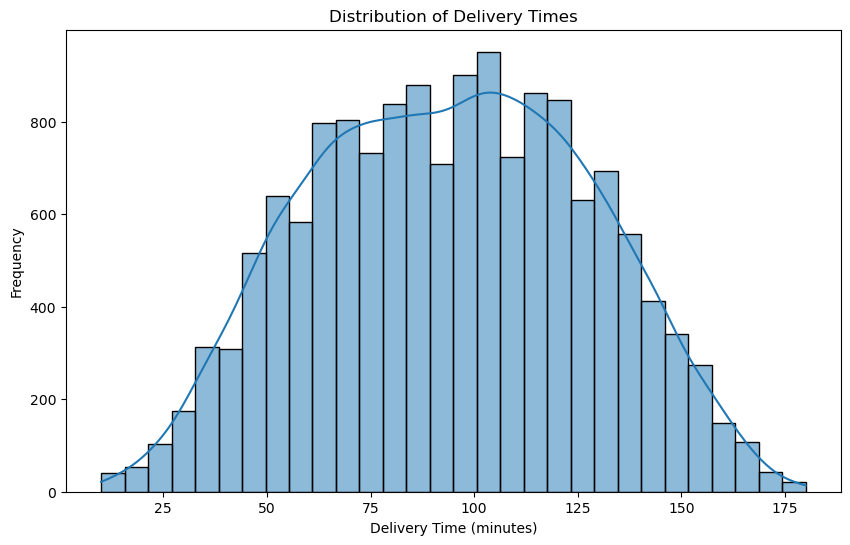

In [98]:
#Distribution of delivery times
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time_minutes'], bins=30, kde=True)
plt.title('Distribution of Delivery Times')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()


In [99]:
# Create late label (SLA Threshold > 120 mins)
df['is_late'] = (df['delivery_time_minutes'] > 120).astype(int)

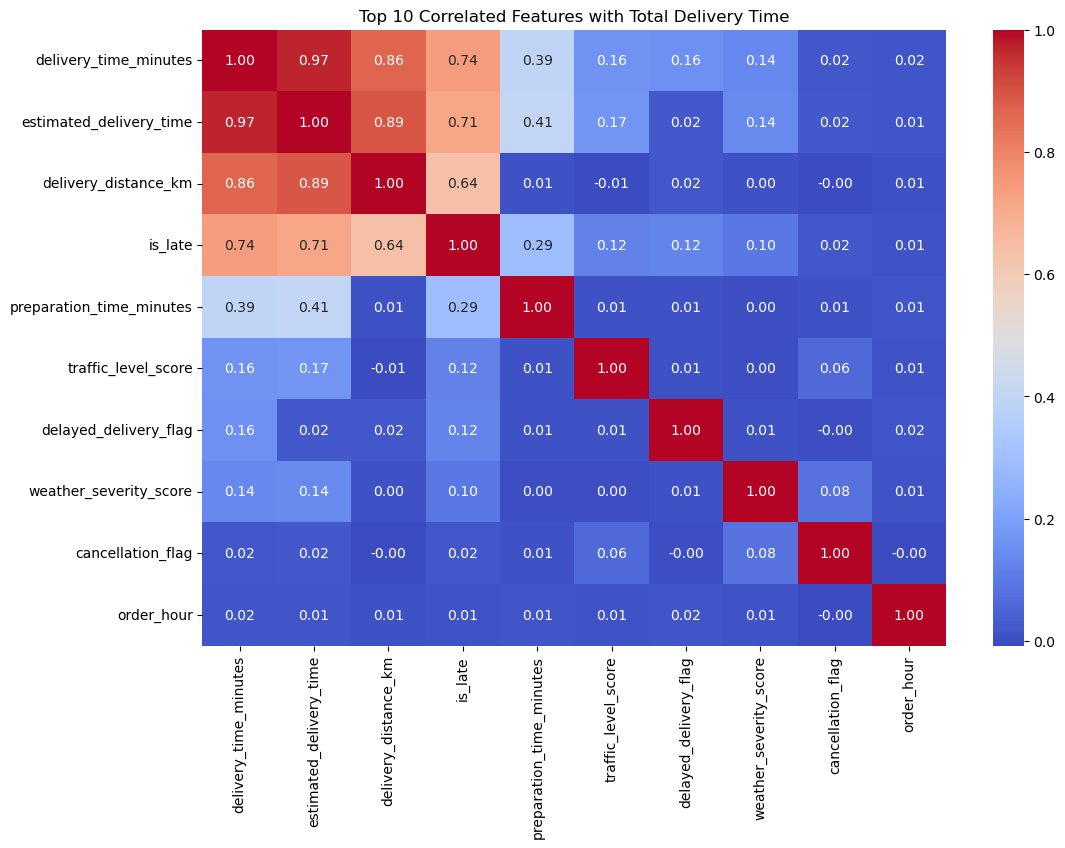

In [100]:
#Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['number', 'bool']).columns
corr_matrix = df[numeric_cols].corr()

#Top 10 features correlated with delivery time
top_features = corr_matrix['delivery_time_minutes'].sort_values(ascending=False).index[:10]
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Correlated Features with Total Delivery Time')
plt.show()

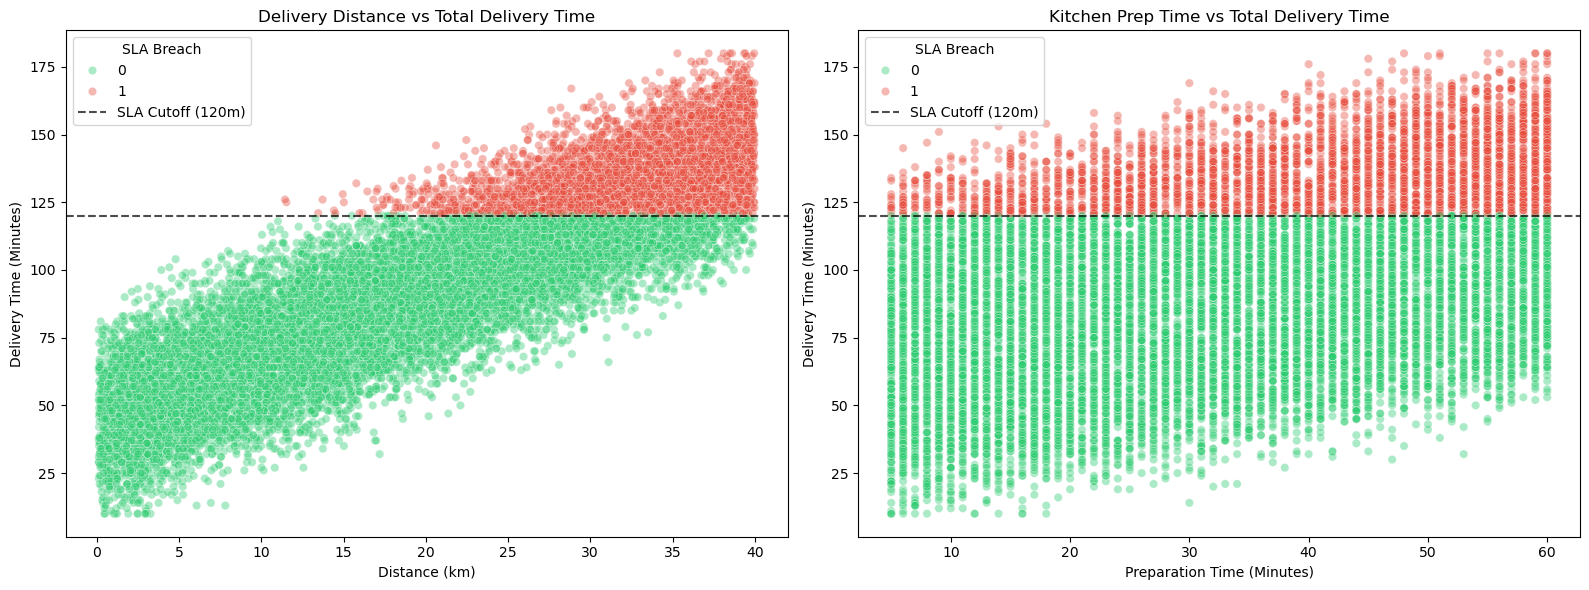

In [101]:
#Plotting key relationships

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distance vs Delivery Time
sns.scatterplot(data=df, x='delivery_distance_km', y='delivery_time_minutes', 
                hue='is_late', palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.4, ax=axes[0])
axes[0].axhline(120, color='black', linestyle='--', alpha=0.7, label='SLA Cutoff (120m)')
axes[0].set_title('Delivery Distance vs Total Delivery Time')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Delivery Time (Minutes)')
axes[0].legend(title='SLA Breach')

# Prep Time vs Delivery Time
sns.scatterplot(data=df, x='preparation_time_minutes', y='delivery_time_minutes', 
                hue='is_late', palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.4, ax=axes[1])
axes[1].axhline(120, color='black', linestyle='--', alpha=0.7, label='SLA Cutoff (120m)')
axes[1].set_title('Kitchen Prep Time vs Total Delivery Time')
axes[1].set_xlabel('Preparation Time (Minutes)')
axes[1].set_ylabel('Delivery Time (Minutes)')
axes[1].legend(title='SLA Breach')

plt.tight_layout()
plt.show()

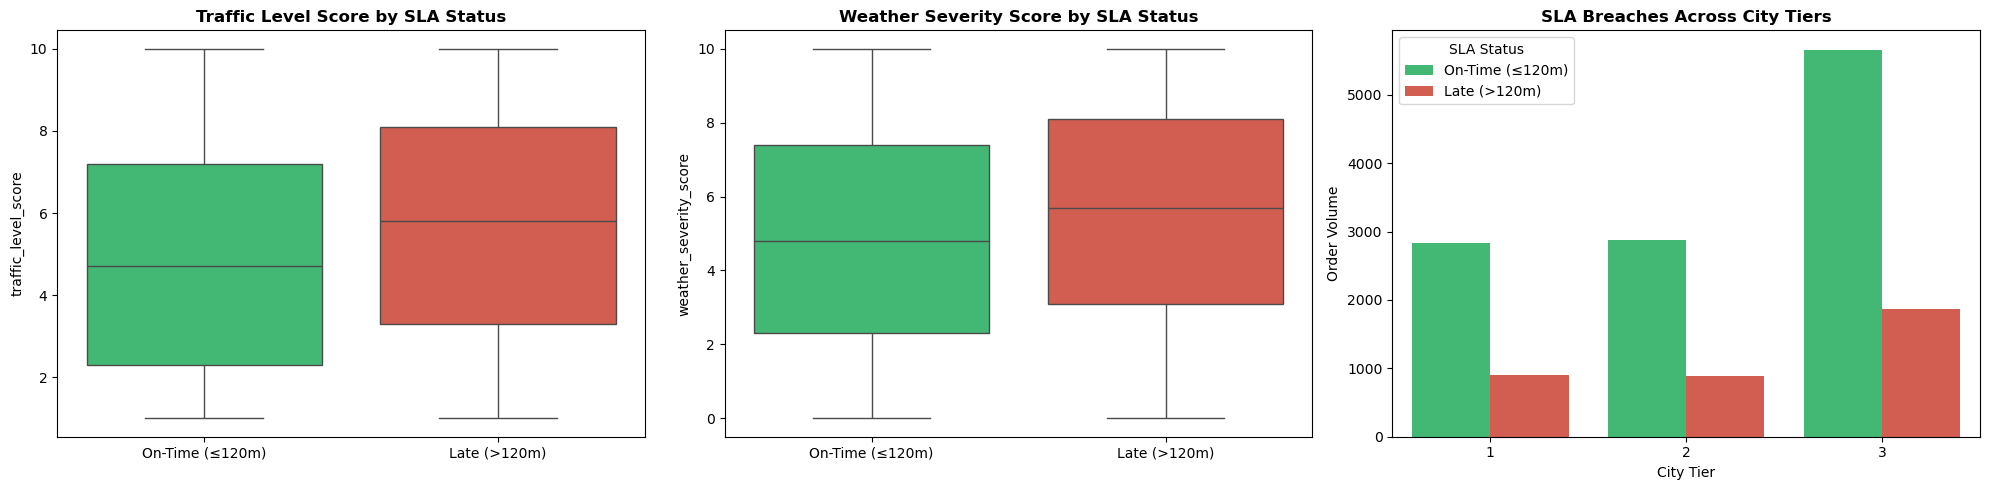

In [102]:
#Plotting SLA breaches by traffic, weather, and city tier

# Create a string column for visualization 
df['SLA_Status'] = np.where(df['delivery_time_minutes'] > 120, 'Late (>120m)', 'On-Time (≤120m)')

# Define the color palette
status_palette = {
    'On-Time (≤120m)': '#2ecc71',  # Green
    'Late (>120m)': '#e74c3c'      # Red
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Traffic Score Distributions 
sns.boxplot(data=df, x='SLA_Status', y='traffic_level_score', hue='SLA_Status', palette=status_palette, ax=axes[0], legend=False)
axes[0].set_title('Traffic Level Score by SLA Status', fontweight='bold')
axes[0].set_xlabel('')

# Weather Severity Distributions
sns.boxplot(data=df, x='SLA_Status', y='weather_severity_score', hue='SLA_Status', palette=status_palette, ax=axes[1], legend=False)
axes[1].set_title('Weather Severity Score by SLA Status', fontweight='bold')
axes[1].set_xlabel('')

# City Tier Volumes vs Breaches
sns.countplot(data=df, x='city_tier', hue='SLA_Status', palette=status_palette, ax=axes[2])
axes[2].set_title('SLA Breaches Across City Tiers', fontweight='bold')
axes[2].set_xlabel('City Tier')
axes[2].set_ylabel('Order Volume')
axes[2].legend(title='SLA Status')

plt.tight_layout()
plt.show()

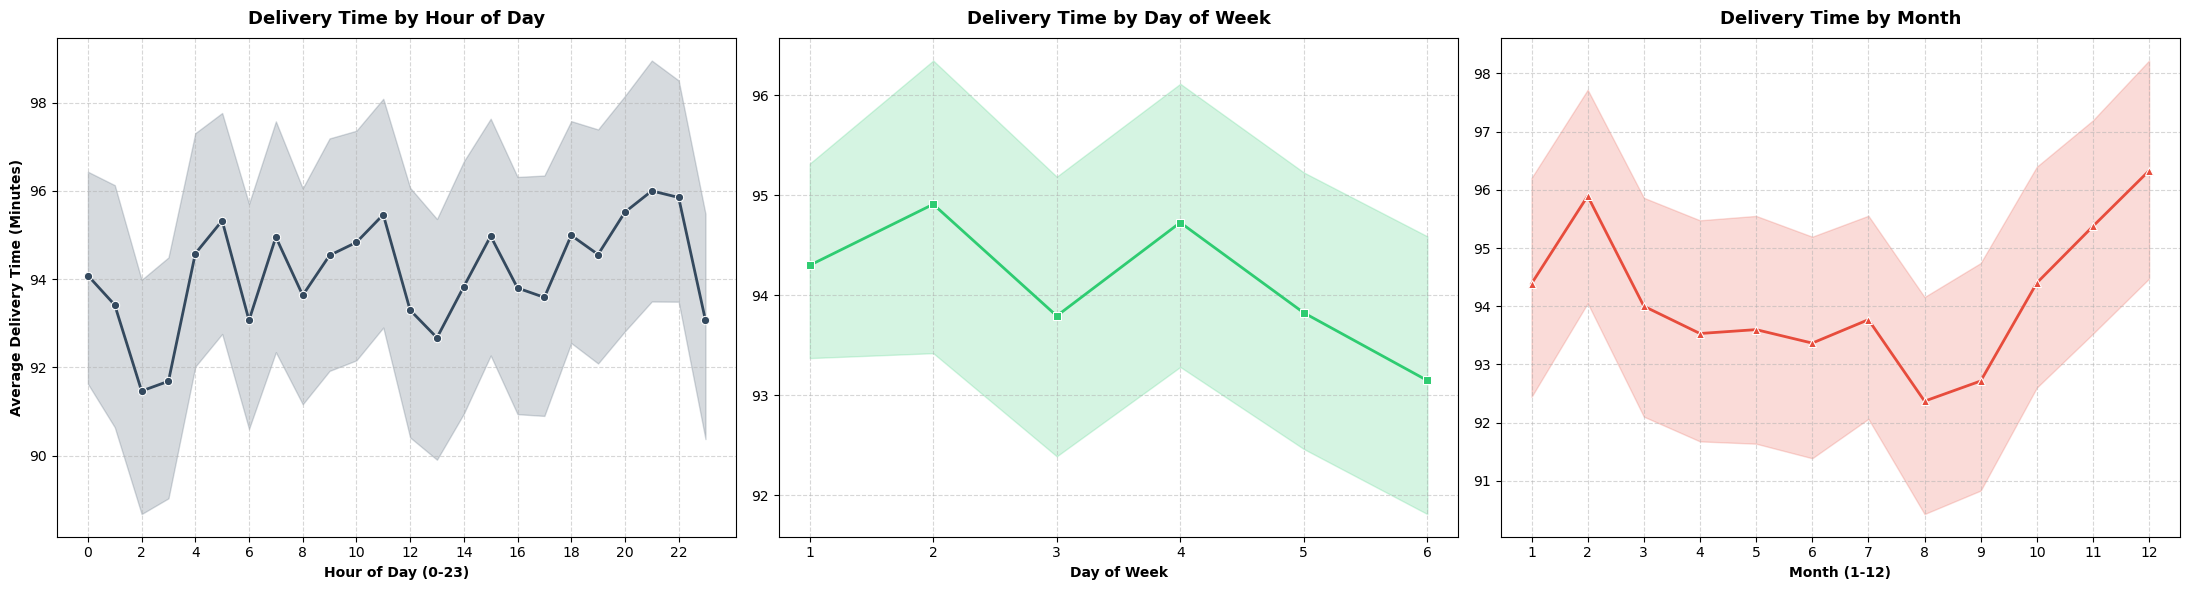

In [103]:
#Plotting temporal trends in delivery times by hour, day of week, and month

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Hour of Day vs Delivery Time
sns.lineplot(data=df, x='order_hour', y='delivery_time_minutes', marker='o', color='#34495e', linewidth=2, ax=axes[0])
axes[0].set_title('Delivery Time by Hour of Day', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Hour of Day (0-23)', fontweight='bold')
axes[0].set_ylabel('Average Delivery Time (Minutes)', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))  
axes[0].grid(True, linestyle='--', alpha=0.5)

# Day of the Week vs Delivery Time
sns.lineplot(data=df, x='order_day_of_week', y='delivery_time_minutes', marker='s', color='#2ecc71', linewidth=2, ax=axes[1])
axes[1].set_title('Delivery Time by Day of Week', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Day of Week', fontweight='bold')
axes[1].set_ylabel('')  
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Month of the Year vs Delivery Time
sns.lineplot(data=df, x='order_month', y='delivery_time_minutes', marker='^', color='#e74c3c', linewidth=2, ax=axes[2])
axes[2].set_title('Delivery Time by Month', fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Month (1-12)', fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_xticks(range(1, 13))  
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

DATA PREPROCESSING

In [104]:
#Feature engineering

def engineer_logistics_features(X):
    X_out = X.copy()
    
    # Feature 1: Distance-Traffic Burden
    X_out['distance_traffic_burden'] = X_out['delivery_distance_km'] * X_out['traffic_level_score']
    
    # Feature 2: Total Environmental Score
    X_out['env_score'] = X_out['traffic_level_score'] + X_out['weather_severity_score']
    
    
    return X_out

In [105]:
#Split data into features and target

#Target variable
y = df['delivery_time_minutes']

# Drop columns that are not useful for prediction or could introduce bias
cols_to_drop = [
    'order_id', 'delivery_time_minutes', 'estimated_delivery_time',
    'customer_rating', 'cancellation_flag', 'delayed_delivery_flag', 'refund_flag',
    'customer_age', 'customer_loyalty_score',  
    'SLA_Status', 'is_late', 'final_amount_paid', 'discount_amount',
    'delivery_fee', 'promo_code_used', 'order_value', 'tip_amount', 'delivery_efficiency_score'
]

#Feature set
X = df.drop(columns=cols_to_drop)

In [106]:
#Split data for training and testing

# Standard 3-way split (60% Train / 20% Val / 20% Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

#Check shapes of splits
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((9000, 14), (9000,), (3000, 14), (3000,), (3000, 14), (3000,))

In [107]:
#Transform categorical features and scale numerical features

# Numeric features to be imputed and scaled
numeric_features = [
    'delivery_distance_km', 'preparation_time_minutes', 'traffic_level_score', 
    'weather_severity_score', 'restaurant_rating', 'delivery_partner_rating', 
     'number_of_items', 'delivery_partner_experience_years', 
    'distance_traffic_burden', 'env_score'
]

# Categorical/temporal structural columns
categorical_features = [
    'city_tier', 'order_hour', 'order_day_of_week', 'order_month',
     'premium_customer_flag', 'festival_or_weekend_flag'
]

# Numeric Preprocessing: Median Imputation + Z-score Scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Preprocessing: Mode Imputation + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine transformations into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' 
)


MODEL BUILDING

In [108]:
#Define a function to create pipelines for different models

# This guarantees that feature engineering and preprocessing remain identical across all 3 models.
def create_model_pipeline(model_estimator):
    return Pipeline(steps=[
        ('feature_engineering', FunctionTransformer(engineer_logistics_features)),
        ('preprocessor', preprocessor),
        ('model', model_estimator)
    ])

In [ ]:
#Model 1: Linear Regression

print("--- Training Model 1: Linear Regression ---")
lr_pipeline = create_model_pipeline(LinearRegression())
lr_pipeline.fit(X_train, y_train)

--- Training Model 1: Linear Regression ---


Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_logistics_features at 0x751a3cb91310>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['delivery_distance_km',
                                                   'preparation_time_minutes',
                                                   'traffic_level_score',
                                                   'weather_se...
                                                   'delivery_partner_experience_years',
                                                   'distance_traffic_burden',
                                                   'env_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['city_tier', 'order_hour',
                                                   'order_day_of_week',
                                                   'order_month',
                                                   'premium_customer_flag',
                                                   'festival_or_weekend_flag'])])),
                ('model', LinearRegression())])

In [ ]:
#Model 2: Random Forest Regressor with Hyperparameter Tuning

print("\n--- Tuning Model 2: Random Forest ---")
rf_pipeline = create_model_pipeline(RandomForestRegressor(random_state=42))

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [6, 12],
    'model__min_samples_split': [2, 5]
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,  # 3-Fold CV keeps execution runtime reasonable
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)
best_rf_pipeline = rf_grid_search.best_estimator_
print("Best Parameters for Random Forest:", rf_grid_search.best_params_)


--- Tuning Model 2: Random Forest ---


Best Parameters for Random Forest: {'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [111]:
#Hyperparameter tuning for Random Forest - Expanded Grid Search
rf_param_grid = {
    'model__n_estimators': [200, 300, 500],       # Shifting up from 100/200
    'model__max_depth': [12, 16, 20, None],        # Shifting up from 6/12; None allows maximum growth
    'model__min_samples_split': [2, 5]             # Keeping 2 as an option since it was preferred
}

print("Running expanded grid search for Random Forest...")
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)
rf_grid_search.fit(X_train, y_train)

best_rf_pipeline = rf_grid_search.best_estimator_
print("New Best Parameters:", rf_grid_search.best_params_)

Running expanded grid search for Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END model__max_depth=12, model__min_samples_split=5, model__n_estimators=200; total time=  16.2s
[CV] END model__max_depth=12, model__min_samples_split=5, model__n_estimators=200; total time=  16.6s
[CV] END model__max_depth=12, model__min_samples_split=5, model__n_estimators=200; total time=  17.2s
[CV] END model__max_depth=12, model__min_samples_split=2, model__n_estimators=200; total time=  17.7s
[CV] END model__max_depth=12, model__min_samples_split=2, model__n_estimators=200; total time=  17.8s
[CV] END model__max_depth=12, model__min_samples_split=2, model__n_estimators=200; total time=  19.2s
[CV] END model__max_depth=16, model__min_samples_split=2, model__n_estimators=200; total time=  21.7s
[CV] END model__max_depth=16, model__min_samples_split=2, model__n_estimators=200; total time=  22.3s
[CV] END model__max_depth=12, model__min_samples_split=5, model__n_estima

In [112]:
#Model 3: XGBoost Regressor with Hyperparameter Tuning
print("\n--- Tuning Model 3: XGBoost ---")
xgb_pipeline = create_model_pipeline(XGBRegressor(random_state=42))

xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)
xgb_grid_search.fit(X_train, y_train)
best_xgb_pipeline = xgb_grid_search.best_estimator_
print("Best Parameters for XGBoost:", xgb_grid_search.best_params_)


--- Tuning Model 3: XGBoost ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__learning_rate=0.1, model__max_depth=4, model__n_estimators=100; total time=   0.4s[CV] END model__learning_rate=0.1, model__max_depth=4, model__n_estimators=100; total time=   0.4s

[CV] END model__learning_rate=0.1, model__max_depth=4, model__n_estimators=100; total time=   0.4s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__n_estimators=100; total time=   0.4s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__n_estimators=100; total time=   0.4s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__n_estimators=100; total time=   0.4s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__n_estimators=200; total time=   0.6s
[CV] END model__learning_rate=0.1, model__max_depth=4, model__n_estimators=200; total time=   0.6s
[CV] END model__learning_rate=0.1, model__max_depth=6, model__n_estimators=100; total time=   0.6s
[CV] END mod

In [113]:
# Expanded Parameters
xgb_param_grid = {
    'model__n_estimators': [200, 300, 500],      # Pushing up from 100/200
    'model__max_depth': [6, 8, 10],              # Testing deeper structures past 4/6
    'model__learning_rate': [0.05, 0.1, 0.15]    # Testing if a higher learning rate yields better corrections
}

print("Running expanded grid search for XGBoost...")
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2 
)

xgb_grid_search.fit(X_train, y_train)

best_xgb_pipeline = xgb_grid_search.best_estimator_
print("\nNew Optimized XGBoost Parameters:", xgb_grid_search.best_params_)

Running expanded grid search for XGBoost...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200; total time=   0.9s[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200; total time=   0.9s

[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200; total time=   0.9s
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=300; total time=   1.3s
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=300; total time=   1.4s
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=300; total time=   1.5s
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=500; total time=   2.1s
[CV] END model__learning_rate=0.05, model__max_depth=8, model__n_estimators=200; total time=   2.1s
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=500; total time=   

In [ ]:
# Targeted parameter search space for smoothing out linear approximations
xgb_fine_tune_grid = {
    'model__n_estimators': [500, 800, 1000],      # Allow more rounds
    'model__learning_rate': [0.03, 0.05, 0.1],     # Testing smoother learning steps
    'model__max_depth': [4, 5, 6],                 # Keeping depth to prevent overfitting
    'model__reg_lambda': [1, 5, 10],               # L2 regularization to smooth out leaf weights
    'model__alpha': [0, 1, 5]                      # L1 regularization to  dim noisy features
}

print("Running advanced linear-approximation tuning for XGBoost...")
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_fine_tune_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

xgb_grid_search.fit(X_train, y_train)

# Extract optimized, smooth gradient booster
best_xgb_pipeline = xgb_grid_search.best_estimator_
print("\nFinal Optimized XGBoost Parameters:", xgb_grid_search.best_params_)

Running advanced linear-approximation tuning for XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
[CV] END model__alpha=0, model__learning_rate=0.03, model__max_depth=4, model__n_estimators=500, model__reg_lambda=5; total time=   2.2s
[CV] END model__alpha=0, model__learning_rate=0.03, model__max_depth=4, model__n_estimators=500, model__reg_lambda=10; total time=   2.2s
[CV] END model__alpha=0, model__learning_rate=0.03, model__max_depth=4, model__n_estimators=500, model__reg_lambda=5; total time=   2.1s
[CV] END model__alpha=0, model__learning_rate=0.03, model__max_depth=4, model__n_estimators=500, model__reg_lambda=10; total time=   2.2s
[CV] END model__alpha=0, model__learning_rate=0.03, model__max_depth=4, model__n_estimators=500, model__reg_lambda=10; total time=   2.4s
[CV] END model__alpha=0, model__learning_rate=0.03, model__max_depth=4, model__n_estimators=500, model__reg_lambda=1; total time=   2.8s
[CV] END model__alpha=0, model__learning_rate=0.03, 

In [124]:
#Prediction and evaluation on the test set

test_models_dict = {
    'Linear Regression': lr_pipeline,
    'Random Forest': best_rf_pipeline,
    'XGBoost': best_xgb_pipeline
}

test_results = []


for name, pipeline in test_models_dict.items():
    # Make predictions on the test set
    y_test_pred = pipeline.predict(X_test)
    
    # Calculate evaluation benchmarks
    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_test_pred)
    
    test_results.append({
        'Model': name,
        'MAE (Minutes)': round(mae, 2),
        'RMSE (Minutes)': round(rmse, 2),
        'R² Score': round(r2, 4)
    })
    
#Comparing model performance on the test set
df_summary = pd.DataFrame(test_results)
df_summary = df_summary.sort_values(by='MAE (Minutes)', ascending=True).reset_index(drop=True)

# Display the clean results table
print("\n==================================================")
print("             FINAL PERFORMANCE LEADERBOARD        ")
print("==================================================")
display(df_summary)


             FINAL PERFORMANCE LEADERBOARD        


,Model,MAE (Minutes),RMSE (Minutes),R² Score
0,Linear Regression,6.42,8.08,0.9425
1,XGBoost,6.60,8.28,0.9396
2,Random Forest,6.72,8.45,0.9371


All Models are off by about 6 minutes

All Models have about 93% Accuracy

Linear regresssion is winning with this dataset. This is likely because it is synthetic data and a linear relationship already exists

In [127]:
#Selecting the best model (lowest MAE) for final deployment
best_model = df_summary.loc[0, 'Model']
best_pipeline = test_models_dict[best_model]
print(f"\nBest Model Selected for Deployment: {best_model}")

final_pipeline = Pipeline(steps=[
    ('feature_engineering', FunctionTransformer(engineer_logistics_features)),
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
final_pipeline.fit(X_train, y_train)


Best Model Selected for Deployment: Linear Regression


Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_logistics_features at 0x751a3cb91310>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['delivery_distance_km',
                                                   'preparation_time_minutes',
                                                   'traffic_level_score',
                                                   'weather_se...
                                                   'delivery_partner_experience_years',
                                                   'distance_traffic_burden',
                                                   'env_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['city_tier', 'order_hour',
                                                   'order_day_of_week',
                                                   'order_month',
                                                   'premium_customer_flag',
                                                   'festival_or_weekend_flag'])])),
                ('model', LinearRegression())])

In [129]:
# Serialize the pipeline 
os.makedirs('models', exist_ok=True)
pickle_path = 'models/delivery_time_pipeline.pkl'

with open(pickle_path, 'wb') as file:
    pickle.dump(final_pipeline, file)

print(f"\nPipeline successfully saved to disk at: {pickle_path}")


Pipeline successfully saved to disk at: models/delivery_time_pipeline.pkl


SLA BREACH EVALUATION

In [137]:
# Generate final predictions using your serialized/loaded Linear Regression champion
y_test_pred = final_pipeline.predict(X_test)

# Clean dataframe dedicated strictly to SLA evaluation
df_waterfall = pd.DataFrame({
    'Actual_Time': y_test,
    'Predicted_Time': y_test_pred
}).reset_index(drop=True)

#Binning into risk categories based on SLA thresholds
def assign_sla_risk_tier(minutes):
    if minutes < 100:
        return 'Safe (<100m)'
    elif 100 <= minutes <= 120:
        return 'At-Risk (100-120m)'
    else:
        return 'SLA Breach (>120m)'

# Apply the transformation to both continuous columns
df_waterfall['Actual_Risk_Tier'] = df_waterfall['Actual_Time'].apply(assign_sla_risk_tier)
df_waterfall['Predicted_Risk_Tier'] = df_waterfall['Predicted_Time'].apply(assign_sla_risk_tier)

# Create binary indicators for True SLA Breaches vs Predicted SLA Breaches
df_waterfall['Actual_Breach_Flag'] = (df_waterfall['Actual_Time'] > 120).astype(int)
df_waterfall['Predicted_Breach_Flag'] = (df_waterfall['Predicted_Time'] > 120).astype(int)

print("Predictions")
print("\n[Actual Reality Distribution]:")
print(df_waterfall['Actual_Risk_Tier'].value_counts())

print("\n[Model Prediction Distribution]:")
print(df_waterfall['Predicted_Risk_Tier'].value_counts())

display(df_waterfall.head(10))

Predictions

[Actual Reality Distribution]:
Actual_Risk_Tier
Safe (<100m)          1692
SLA Breach (>120m)     725
At-Risk (100-120m)     583
Name: count, dtype: int64

[Model Prediction Distribution]:
Predicted_Risk_Tier
Safe (<100m)          1706
SLA Breach (>120m)     728
At-Risk (100-120m)     566
Name: count, dtype: int64


,Actual_Time,Predicted_Time,Actual_Risk_Tier,Predicted_Risk_Tier,Actual_Breach_Flag,Predicted_Breach_Flag
0,106,116.256419,At-Risk (100-120m),At-Risk (100-120m),0,0
1,140,136.041707,SLA Breach (>120m),SLA Breach (>120m),1,1
2,64,72.065435,Safe (<100m),Safe (<100m),0,0
3,120,124.977561,At-Risk (100-120m),SLA Breach (>120m),0,1
4,35,47.809927,Safe (<100m),Safe (<100m),0,0
5,160,150.224055,SLA Breach (>120m),SLA Breach (>120m),1,1
6,164,160.551389,SLA Breach (>120m),SLA Breach (>120m),1,1
7,132,135.010101,SLA Breach (>120m),SLA Breach (>120m),1,1
8,130,119.762456,SLA Breach (>120m),At-Risk (100-120m),1,0
9,109,121.290437,At-Risk (100-120m),SLA Breach (>120m),0,1


In [139]:
#Confusion Matrix for SLA Breach Prediction
# 0 = On-Time/Safe, 1 = SLA Breach (>120 minutes)
cm = confusion_matrix(df_waterfall['Actual_Breach_Flag'], df_waterfall['Predicted_Breach_Flag'])
tn, fp, fn, tp = cm.ravel()

# Create display
df_cm = pd.DataFrame(
    cm, 
    columns=['Predicted: ON-TIME', 'Predicted: BREACH'],
    index=['Actual: ON-TIME', 'Actual: BREACH']
)

print("==================================================")
print("             SLA BREACH CONFUSION MATRIX          ")
print("==================================================")
display(df_cm)

print(f"\nBreakdown Analysis:")
print(f"• True Negatives: {tn}")
print(f"• True Positives: {tp}")
print(f"• False Positives: {fp}")
print(f"• False Negatives: {fn}")

#Classification Report for SLA Breach Prediction
print("\n==================================================")
print("             CLASSIFICATION REPORT                ")
print("==================================================")
print(classification_report(
    df_waterfall['Actual_Breach_Flag'], 
    df_waterfall['Predicted_Breach_Flag'],
    target_names=['On-Time (<=120m)', 'SLA Breach (>120m)']
))

             SLA BREACH CONFUSION MATRIX          


,Predicted: ON-TIME,Predicted: BREACH
Actual: ON-TIME,2174,101
Actual: BREACH,98,627



Breakdown Analysis:
• True Negatives: 2174
• True Positives: 627
• False Positives: 101
• False Negatives: 98

             CLASSIFICATION REPORT                
                    precision    recall  f1-score   support

  On-Time (<=120m)       0.96      0.96      0.96      2275
SLA Breach (>120m)       0.86      0.86      0.86       725

          accuracy                           0.93      3000
         macro avg       0.91      0.91      0.91      3000
      weighted avg       0.93      0.93      0.93      3000



The system has an overall accuracy of 93%

The system successfully catches 86% of all operational failures.

ANALYSIS

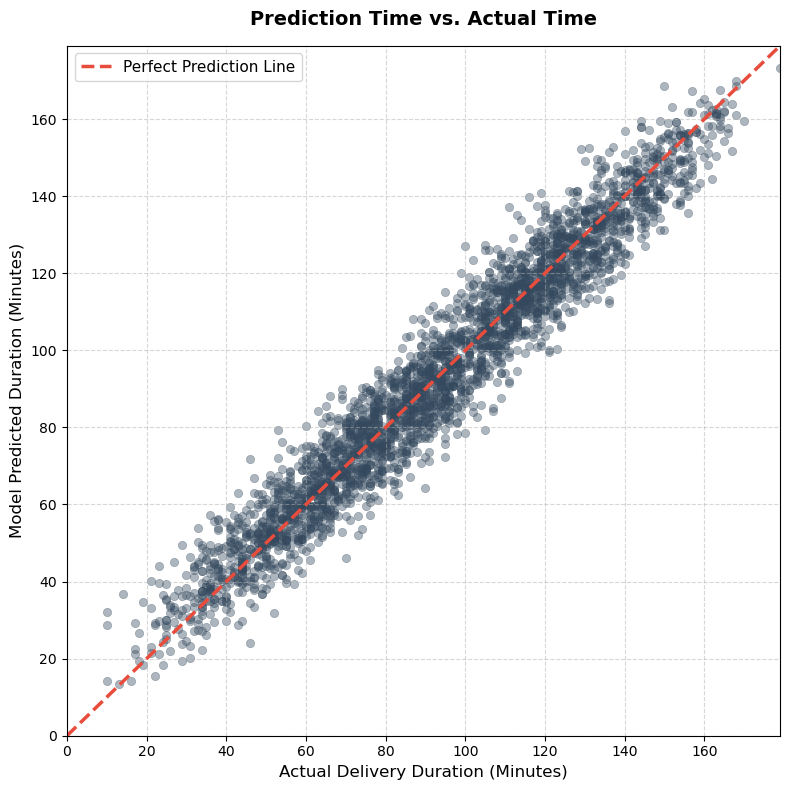

In [141]:
# Model Reliability
# Prediction time vs Actual time

plt.figure(figsize=(8, 8))

# Plot actual vs predicted scatter
sns.scatterplot(
    data=df_waterfall, 
    x='Actual_Time', 
    y='Predicted_Time', 
    alpha=0.4, 
    color='#34495e',
    edgecolor=None
)

# Overlay a perfect prediction line (y=x) for reference
max_val = max(df_waterfall['Actual_Time'].max(), df_waterfall['Predicted_Time'].max())
plt.plot([0, max_val], [0, max_val], color='#e74c3c', linestyle='--', linewidth=2.5, label='Perfect Prediction Line')

plt.title('Prediction Time vs. Actual Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Delivery Duration (Minutes)', fontsize=12)
plt.ylabel('Model Predicted Duration (Minutes)', fontsize=12)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/tmp/ipykernel_19301/3678339253.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


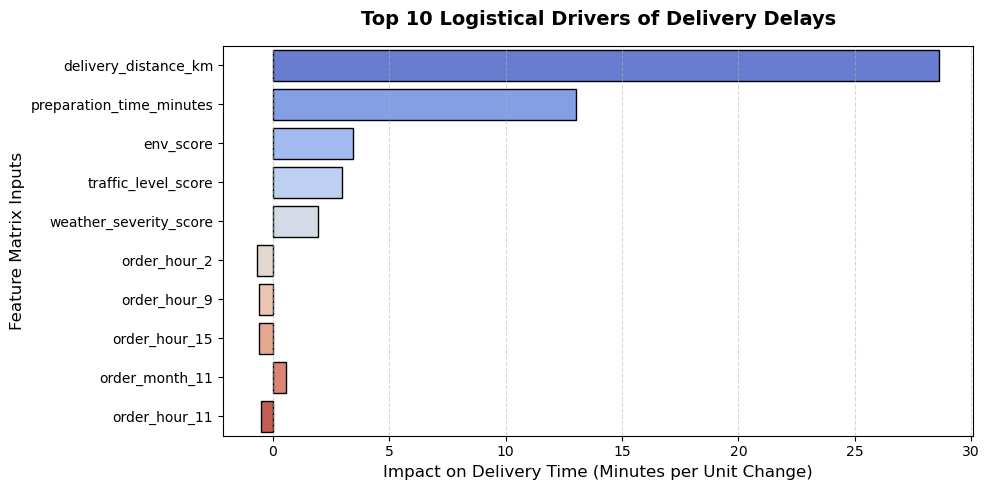

In [ ]:
# Extract the final linear regression model coefficients
lr_model = final_pipeline.named_steps['model']

# Re-map the exact feature names passing through our preprocessor
feature_names = numeric_features + list(
    final_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)
coefficients = lr_model.coef_

#FEATURE IMPORTANCE VISUALIZATION: TOP DRIVERS OF DELIVERY DELAYS

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Filter down to the top 10 most impactful contributors for presentation clarity
df_top_features = df_importance.iloc[np.argsort(df_importance['Coefficient'].abs())[::-1][:10]]

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_top_features, 
    x='Coefficient', 
    y='Feature', 
    palette=sns.color_palette("coolwarm", len(df_top_features)),
    edgecolor='black'
)
plt.title('Top 10 Drivers of Delivery Delays', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Impact on Delivery Time (Minutes per Unit Change)', fontsize=12)
plt.ylabel('Feature Matrix Inputs', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [148]:

# CUSTOMER SEGMENTATION BIAS AUDIT

# Re-attach the isolated downstream metadata
df_audit = df_waterfall.copy()
df_audit['customer_loyalty_score'] = df.loc[X_test.index, 'customer_loyalty_score'].values
df_audit['customer_age'] = df.loc[X_test.index, 'customer_age'].values
df_audit['premium_customer_flag'] = df.loc[X_test.index, 'premium_customer_flag'].values
df_audit['city_tier'] = df.loc[X_test.index, 'city_tier'].values

# Calculate Absolute Error for each individual prediction row
df_audit['Absolute_Error'] = (df_audit['Actual_Time'] - df_audit['Predicted_Time']).abs()

# Establish segments based on Customer Loyalty Tiering
def categorize_loyalty(score):
    if score >= 8.0: return 'VIP Elite (8.0-10.0)'
    elif 5.0 <= score < 8.0: return 'Core Retained (5.0-7.9)'
    else: return 'Casual/New (<5.0)'

df_audit['Loyalty_Segment'] = df_audit['customer_loyalty_score'].apply(categorize_loyalty)

# Establish segments based on Customer Generational Age Tiers
def categorize_age(age):
    if age < 25: return 'Gen Z (<25)'
    elif 25 <= age <= 40: return 'Millennials (25-40)'
    else: return 'Gen X/Boomer (>40)'

df_audit['Age_Segment'] = df_audit['customer_age'].apply(categorize_age)

# Mapping that catches integers, floats, strings, and booleans
def categorize_premium(val):
    # Normalize string representations to lowercase
    str_val = str(val).strip().lower()
    if str_val in ['1', '1.0', 'true', 'yes', 'premium']:
        return 'Premium Member'
    else:
        return 'Standard User'

df_audit['Customer_Status'] = df_audit['premium_customer_flag'].apply(categorize_premium)

# Compute Mean Absolute Error broken across all four segments
loyalty_summary = df_audit.groupby('Loyalty_Segment')['Absolute_Error'].mean().round(2)
age_summary = df_audit.groupby('Age_Segment')['Absolute_Error'].mean().round(2)
premium_summary = df_audit.groupby('Customer_Status')['Absolute_Error'].mean().round(2)
city_summary = df_audit.groupby('city_tier')['Absolute_Error'].mean().round(2)

print("\n======================================================================")
print("             CUSTOMER BIAS AUDIT: SEGMENT ACCURACY                ")
print("======================================================================")
print("\n[MAE across Customer Loyalty Tiers]:")
print(loyalty_summary.to_string())

print("\n[MAE across Customer Generational Age Tiers]:")
print(age_summary.to_string())

print("\n[MAE across Premium Account Status]:")
print(premium_summary.to_string())

print("\n[MAE across Geographic City Tiers]:")
print(city_summary.to_string())
print("======================================================================")


             CUSTOMER BIAS AUDIT: SEGMENT ACCURACY                

[MAE across Customer Loyalty Tiers]:
Loyalty_Segment
Casual/New (<5.0)          5.95
Core Retained (5.0-7.9)    6.67
VIP Elite (8.0-10.0)       6.44

[MAE across Customer Generational Age Tiers]:
Age_Segment
Gen X/Boomer (>40)     6.40
Gen Z (<25)            7.05
Millennials (25-40)    6.21

[MAE across Premium Account Status]:
Customer_Status
Premium Member    6.31
Standard User     6.46

[MAE across Geographic City Tiers]:
city_tier
1    6.38
2    6.24
3    6.53


No overt bias found

SUMMARY